# News Sentiment and Stock Price Volatility

## 1. Problem Definition
**Research question:** Does news sentiment correlate with stock price volatility for GOOGL, NVDA, META, AAPL, and MSFT?

**Context:** Financial media and market commentary frequently attribute stock price swings to news coverage — a company gets a wave of headlines and its stock is said to have "reacted." This is often stated as fact, but rarely tested directly. Understanding whether sentiment actually correlates with volatility (rather than just being a convenient narrative after the fact) matters for how we interpret market behavior.

**Why it matters:** Investors, financial journalists, and anyone trying to make sense of day-to-day stock movements would benefit from knowing whether "the market reacted to the news" reflects a real, measurable pattern or is largely a post-hoc storytelling device layered onto price movements that would have happened anyway.

## 2. Data Collection
**yfinance:** Daily OHLCV (open, high, low, close, volume) price data for 5 tickers, pulled via the `yfinance` Python library — an open-source tool providing programmatic access to Yahoo Finance market data for research and educational purposes.

**Finnhub API:** Company news headlines and summaries for the same 5 tickers, pulled via a free-tier API key using the `company-news` endpoint, filtered by ticker symbol and date range. Finnhub was chosen after an initial attempt using the Marketaux API, whose free tier returned articles clustered on only the most recent 1-2 days regardless of the requested date range. Finnhub's free tier advertises up to a year of historical news access; in practice, however, real article coverage was still found to concentrate heavily on the most recent several days of any requested window — a pattern documented further in the Limitations section below.

**Sentiment scoring:** Finnhub does not provide a built-in sentiment score, so sentiment was computed directly from each article's headline and summary text using **VADER** (Valence Aware Dictionary and sEntiment Reasoner), a lexicon-based sentiment analysis tool from the `nltk` library, well-suited to short, informal text.

## 3. Data Description
- **Stocks used:** GOOGL (Alphabet), NVDA (Nvidia), META (Meta Platforms), AAPL (Apple), MSFT (Microsoft) — chosen as a coherent Big Tech/AI sector group
- **Variables:**
  - *Daily return* (derived from `Close` price via `pct_change()`), used as the volatility proxy — the "effect" side of the question
  - *Average daily sentiment score* (VADER compound score, averaged across all matching articles for that ticker/day) — the "cause" side being tested
  - *Article count* (number of articles per ticker per day) — tracks coverage intensity independent of sentiment direction
- **Number of observations:** 13 (ticker, date) rows in the final merged dataset, after an inner join between price data and daily sentiment: AAPL (3), GOOGL (3), META (3), MSFT (3), NVDA (1)
- **Missing values:** News and price data only overlapped for a narrow window (September 8-11, 2026); trading days outside that overlap have price data but no matched sentiment, and were excluded by the inner join rather than filled with a placeholder sentiment value. NVDA's coverage was concentrated on September 11-12, and the September 12 article had no matching price row (outside the available price data range), leaving only 1 usable NVDA observation.

## 4. Data Cleaning and Preparation
- Reshaped price data from wide format (one column set per ticker) to long format (one row per date + ticker) so it could be merged with news data on shared keys.
- Combined each article's headline and summary into one text field, then scored it with VADER to produce a `sentiment_score` per article.
- Dropped articles with no usable text (and therefore no sentiment score) and duplicate articles (same ticker, same date, same headline).
- Converted article publish timestamps (Unix format) to a plain date (day-level, no time) to align with price data's date granularity.
- Averaged sentiment scores per (ticker, date) to produce one daily sentiment value per ticker, along with an article count for that day.
- Merged price and sentiment data on (ticker, date) using an inner join, keeping only days present in both datasets rather than filling missing news days with a neutral/zero sentiment placeholder.

## 5. Exploratory Data Analysis

### Visualization 1: Daily Return vs. Average News Sentiment, by Ticker
A scatter plot of all 13 observations, sentiment on the x-axis and same-day return on the y-axis, colored by ticker. Every observation in the sample had net-positive sentiment (no negative-sentiment day appeared in the data at all), so this chart shows how the *strength* of positive sentiment related to returns, rather than a positive-vs-negative comparison. Points are broadly scattered with no single clean upward or downward trend across the full set — high-sentiment points appear at both slightly positive and clearly negative returns, and the single largest positive return in the sample (META) occurs at one of the *lower* sentiment values, not the highest.

### Visualization 2: Correlation Between Sentiment and Return, by Ticker
A bar chart of the return-sentiment correlation coefficient calculated separately for each ticker. AAPL shows a positive correlation (+0.63), while GOOGL (-0.86), META (-0.89), and MSFT (-0.74) all show strong negative correlations. NVDA is excluded from this chart since a single data point cannot produce a meaningful correlation coefficient.

## 6. Findings / Storytelling
Across the full sample, daily return and news sentiment showed a moderate *negative* overall correlation (r = -0.53) — the opposite of what a simple "positive news drives positive returns" narrative would predict. However, this overall number masks sharp disagreement between companies: AAPL showed a clear positive relationship (r = +0.63), while GOOGL, META, and MSFT all showed strong negative relationships in a similar range. NVDA's single matching observation wasn't enough data to calculate a meaningful correlation.

One important caveat shapes this result: every observation in the sample happened to have net-positive average sentiment — no clearly negative-sentiment day existed in this short window. These findings speak to how the *strength* of positive coverage related to returns, not a true positive-vs-negative comparison, which limits how directly the results answer the original research question.

Given the inconsistency across companies — three tickers moving one direction, one ticker moving the opposite direction, on the same basic relationship — it would be inaccurate to conclude that news sentiment reliably predicts stock returns for these companies. If anything, the sharp per-ticker disagreement supports the opposite reading: "the market reacted to the news" may describe individual, idiosyncratic cases well after the fact, but it does not hold up as a consistent, generalizable pattern across even a small handful of comparable large-cap tech stocks.

**What would be incorrect to conclude:** It would be incorrect to conclude from this data that news sentiment has *no* effect on stock price — the sample is small (13 observations across 5 tickers over roughly one week), covers only positive-sentiment days, and doesn't control for other factors driving each stock's price on a given day. A larger, longer-running sample with genuine variation in sentiment direction would be needed to test this relationship more rigorously. Correlation observed here also does not establish that sentiment *causes* return movement, or vice versa — both could be responding to some third factor (e.g., an earnings report) simultaneously.

## 7. Limitations and Ethics

**Dataset limitations:** This project went through three different free-tier news APIs before landing on a usable dataset, and that process itself became a core limitation worth documenting. Marketaux's free tier returned articles regardless of the requested date range, consistently limited to only the most recent 1-2 days of coverage. Research into Alpha Vantage's free tier showed a similarly restrictive daily request cap (25/day) that would have made a wide date range impractical. Finnhub, chosen for its documented "1 year of historical news" free-tier allowance and generous 60-requests-per-minute limit, still showed the same underlying pattern in practice: pulling 240+ raw articles per ticker across a 6-week requested window, nearly all of them clustered on the final 3-4 days before the pull date, regardless of how far back the date range was set. The practical result was a final sample of only 13 (ticker, date) observations across 5 companies over roughly one week (September 8-11, 2026), rather than the multi-month window originally planned.

A second limitation is that every single observation in this sample happened to have net-positive average sentiment — no day with net-negative sentiment appeared in the data at all. This means the analysis could only examine how the *strength* of positive sentiment related to returns, not a true positive-versus-negative comparison, which was the original intent of the research question.

A third limitation is uneven coverage across tickers: NVDA had only 1 matching (ticker, date) observation, compared to 3 for the other four companies, because NVDA's available news happened to concentrate on September 11-12, and September 12 fell just outside the range of available price data. As a result, no meaningful correlation could be calculated for NVDA specifically, and any interpretation of its single data point should be treated as anecdotal rather than representative.

Sentiment itself was scored using VADER, a general-purpose, lexicon-based sentiment tool — not one trained specifically on financial language. VADER may misread finance-specific phrasing (e.g., "beat estimates" or "missed guidance") that a finance-tuned model like FinBERT would score more accurately, since VADER evaluates words based on general-language sentiment associations rather than domain-specific context.

Finally, stock price movement is driven by many factors beyond news sentiment — macroeconomic conditions, sector-wide trends, and broader market movement — none of which are controlled for here. Any correlation (or lack of one) observed in this analysis should not be interpreted as a causal relationship between sentiment and price movement.

**Potential biases:** News coverage volume varied by company and by day (article counts per matched observation ranged from 42 to 167), so daily sentiment averages are based on very different sample sizes of underlying articles from day to day, which affects how reliable each daily average actually is. Additionally, the five tickers selected are all large-cap, heavily-covered technology companies; findings here may not generalize to smaller or less-covered stocks with sparser news coverage.

**What I'd explore next:** A paid-tier news API with genuine multi-month historical access would remove the central constraint this project ran into. A finance-tuned sentiment model (e.g., FinBERT) in place of general-purpose VADER would likely produce more accurate sentiment scores. A longer time window with genuine variation in sentiment direction (both positive and negative days) would allow the originally-intended positive-vs-negative comparison. Finally, controlling for broader market movement (e.g., comparing each stock's return against a sector ETF like XLK) would help isolate company-specific sentiment effects from general market conditions.

## 8. References

Heston, S. L., & Sinha, N. R. (2017). News vs. sentiment: Predicting stock returns from news stories. *Financial Analysts Journal, 73*(3), 67–83. https://doi.org/10.2469/faj.v73.n3.3

Hutto, C. J., & Gilbert, E. (2014). VADER: A parsimonious rule-based model for sentiment analysis of social media text. *Proceedings of the International AAAI Conference on Web and Social Media, 8*(1), 216–225. https://doi.org/10.1609/icwsm.v8i1.14550

Wan, X., Yang, J., Marinov, S., Calliess, J. P., Zohren, S., & Dong, X. (2021). Sentiment correlation in financial news networks and associated market movements. *Scientific Reports, 11*(1). https://doi.org/10.1038/s41598-021-82338-6

## 9. AI Usage Disclosure
Generative AI (Claude, Anthropic) was used throughout this project for: explaining API integration concepts (yfinance, Marketaux, Finnhub), debugging code errors (KeyError troubleshooting, merge issues, date range mismatches across three different APIs), and structuring the written report sections. All code was reviewed, run, and adjusted by the student; AI was not used to generate analytical conclusions or write the findings/storytelling section, which reflect the student's own interpretation of the data.

In [80]:
import os
from dotenv import load_dotenv
import requests
import time
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns 
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [81]:
load_dotenv()
FINNHUB_API_KEY = str(os.getenv("FINNHUB_API_KEY"))

In [82]:
nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()

In [83]:
tickers = ["GOOGL", "NVDA", "META", "AAPL", "MSFT"]

start_str = "2026-09-05"
end_str = "2026-09-12"

price_data_all = yf.download(tickers, start=start_str, end=end_str, group_by="ticker")
price_data_all.head()

[*********************100%***********************]  5 of 5 completed


Ticker            MSFT                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2026-09-08  493.010010  495.190002  490.149994  493.950012  18882300   
2026-09-09  493.070007  494.390015  489.799988  491.649994  12889600   
2026-09-10  488.320007  494.519989  486.000000  492.440002  16038800   
2026-09-11  495.649994  498.970001  492.579987  495.630005  14510500   

Ticker            NVDA                                                 ...  \
Price             Open        High         Low       Close     Volume  ...   
Date                                                                   ...   
2026-09-08  232.849448  233.448783  224.598686  225.477692  122965600  ...   
2026-09-09  225.028199  225.927187  223.210241  223.419998   82955500  ...   
2026-09-10  220.529999  220.990005  217.199997  218.360001  105768000  ...   
2026-09-11  221.240005  222.000000  218.149994  218.289993   88804100  ...   

Ticker            AAPL                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2026-09-08  317.100006  320.700012  314.899994  316.220001  35477100   
2026-09-09  315.489990  319.149994  309.899994  315.339996  65640000   
2026-09-10  316.670013  326.739990  316.510010  326.570007  70011900   
2026-09-11  327.450012  336.220001  326.299988  332.269989  50659000   

Ticker            META                                                
Price             Open        High         Low       Close    Volume  
Date                                                                  
2026-09-08  616.210022  624.799988  609.739990  613.479980  18909700  
2026-09-09  648.640015  657.859985  638.559998  653.690002  35900700  
2026-09-10  653.710022  663.500000  642.140015  644.380005  21531900  
2026-09-11  653.510010  664.239990  646.200012  648.030029  16908400  

[4 rows x 25 columns]

In [84]:
price_frames = []
for ticker in tickers:
    df_t = price_data_all[ticker].copy()
    df_t["ticker"] = ticker
    df_t = df_t.reset_index()
    price_frames.append(df_t)

price_df = pd.concat(price_frames, ignore_index=True)
price_df.columns = [c.lower() for c in price_df.columns]
price_df["date"] = pd.to_datetime(price_df["date"]).dt.date
price_df.head()

,date,open,high,low,close,volume,ticker
0,2026-09-08,335.420013,339.679993,333.220001,338.359985,22915800,GOOGL
1,2026-09-09,331.649994,331.850006,327.899994,330.649994,33151600,GOOGL
2,2026-09-10,328.230011,333.230011,327.739990,332.600006,23557600,GOOGL
3,2026-09-11,335.029999,342.980011,335.029999,338.500000,24677500,GOOGL
4,2026-09-08,232.849448,233.448783,224.598686,225.477692,122965600,NVDA


In [85]:
def fetch_finnhub_news(symbol, start_date, end_date, api_key):
    url = "https://finnhub.io/api/v1/company-news"
    params = {"symbol": symbol, "from": start_date, "to": end_date, "token": api_key}
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"Request failed for {symbol}: {response.status_code}")
        return []
    return response.json()

In [86]:
raw_news = {}
for ticker in tickers:
    raw_news[ticker] = fetch_finnhub_news(ticker, start_str, end_str, FINNHUB_API_KEY)
    print(f"{ticker}: {len(raw_news[ticker])} articles pulled")
    time.sleep(1)

GOOGL: 246 articles pulled
NVDA: 249 articles pulled
META: 249 articles pulled
AAPL: 243 articles pulled
MSFT: 249 articles pulled


In [87]:
news_rows = []
for ticker, articles in raw_news.items():
    for article in articles:
        headline = article.get("headline", "") or ""
        summary = article.get("summary", "") or ""
        text = f"{headline}. {summary}".strip()

        sentiment_score = sia.polarity_scores(text)["compound"] if text else None

        news_rows.append({
            "ticker": ticker,
            "published_at": article.get("datetime"),
            "headline": headline,
            "source": article.get("source"),
            "sentiment_score": sentiment_score,
        })

news_df = pd.DataFrame(news_rows)
news_df["published_at"] = pd.to_datetime(news_df["published_at"], unit="s")

In [88]:
news_df["date"] = news_df["published_at"].dt.date
news_df = news_df.drop_duplicates(subset=["ticker", "date", "headline"])

In [89]:
news_df = news_df.dropna(subset=["sentiment_score"]).copy()
price_df = price_df.dropna(subset=["close"]).copy()

price_df = price_df.sort_values(["ticker", "date"])
price_df["daily_return"] = price_df.groupby("ticker")["close"].pct_change()

daily_sentiment = (
    news_df.groupby(["ticker", "date"])["sentiment_score"]
    .agg(avg_sentiment="mean", article_count="count")
    .reset_index()
)

In [90]:
merged_df = pd.merge(price_df, daily_sentiment, on=["ticker", "date"], how="inner")
merged_df = merged_df.dropna(subset=["daily_return", "avg_sentiment"])
merged_df["sentiment_direction"] = np.where(
    merged_df["avg_sentiment"] > 0, "Positive News", "Negative News"
)

In [91]:
print(merged_df.shape)
print(merged_df.groupby("ticker").size())

(13, 11)
ticker
AAPL     3
GOOGL    3
META     3
MSFT     3
NVDA     1
dtype: int64


In [92]:
print(merged_df[["daily_return", "avg_sentiment", "article_count"]].describe())

print("\nOverall correlation (return vs sentiment):")
print(merged_df["daily_return"].corr(merged_df["avg_sentiment"]))

print("\nCorrelation by ticker:")
print(merged_df.groupby("ticker").apply(
    lambda g: g["daily_return"].corr(g["avg_sentiment"])
))

       daily_return  avg_sentiment  article_count
count     13.000000      13.000000      13.000000
mean       0.008554       0.239128      78.230769
std        0.022538       0.052946      31.244076
min       -0.022786       0.166798      41.000000
25%       -0.002783       0.197042      59.000000
50%        0.005664       0.224850      76.000000
75%        0.017454       0.289398      86.000000
max        0.065544       0.319368     161.000000

Overall correlation (return vs sentiment):
-0.5219011611596266

Correlation by ticker:
ticker
AAPL     0.660179
GOOGL   -0.869044
META    -0.885111
MSFT    -0.742800
NVDA          NaN
dtype: float64


/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/var/folders/rb/ysc67s4n1_x2q6y98v3q5zs40000gn/T/ipykernel_90295/2336620032.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(merged_df.groupby("ticker").apply(


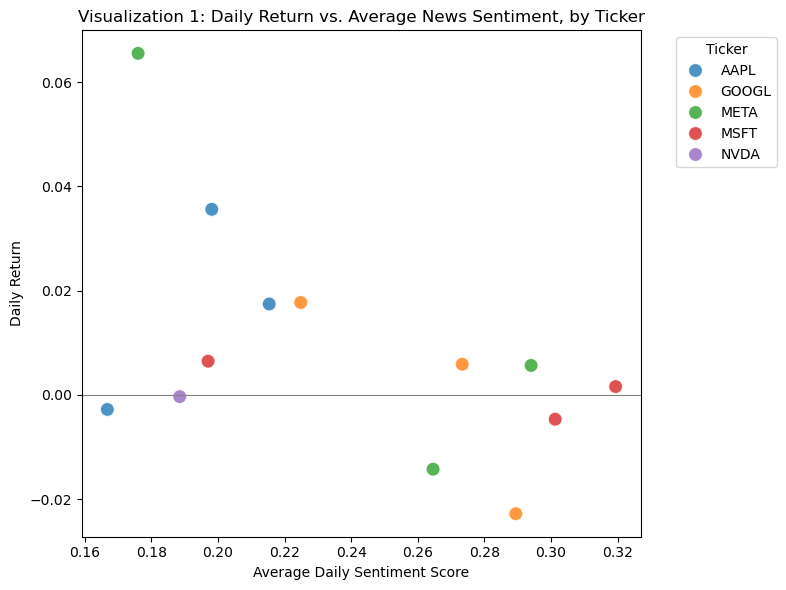

In [93]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=merged_df,
    x="avg_sentiment",
    y="daily_return",
    hue="ticker",
    s=100,
    alpha=0.8,
)
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Visualization 1: Daily Return vs. Average News Sentiment, by Ticker")
plt.xlabel("Average Daily Sentiment Score")
plt.ylabel("Daily Return")
plt.legend(title="Ticker", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

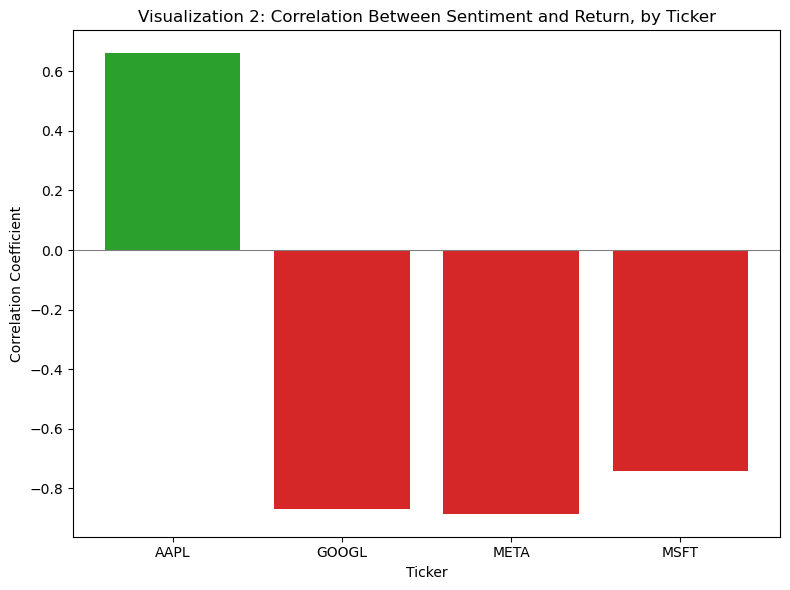

In [94]:
ticker_corr = merged_df.groupby("ticker")[["daily_return", "avg_sentiment"]].apply(
    lambda g: g["daily_return"].corr(g["avg_sentiment"]) if len(g) > 1 else None
).reset_index(name="correlation")

plt.figure(figsize=(8, 6))
colors = ["tab:green" if c > 0 else "tab:red" for c in ticker_corr["correlation"].fillna(0)]
plt.bar(ticker_corr["ticker"], ticker_corr["correlation"], color=colors)
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Visualization 2: Correlation Between Sentiment and Return, by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Correlation Coefficient")
plt.tight_layout()
plt.show()